In [ ]:
from __future__ import annotations
from dataclasses import dataclass, field
import numpy as np
import pynapple as nap
import xarray as xr


@dataclass
class SessionIO:
    """Timing (pynapple) + file manifest (xarray) kept separate but loaded together."""
    trials_ep: nap.IntervalSet          # start/stop times, trial metadata
    media: xr.Dataset                   # file paths (video, audio, ephys, pose)
    stream_offsets: dict[str, float] = field(default_factory=dict)

    # ------------------------------------------------------------------
    # Timing API  (replaces TrialTree timing methods)
    # ------------------------------------------------------------------

    def start_time(self, trial: int) -> float:
        idx = self._trial_idx(trial)
        return float(self.trials_ep.start[idx])

    def stop_time(self, trial: int) -> float | None:
        idx = self._trial_idx(trial)
        return float(self.trials_ep.end[idx])

    def trial_duration(self, trial: int) -> float:
        return self.stop_time(trial) - self.start_time(trial)

    def stream_is_per_trial(self, stream: str) -> bool:
        if stream not in self.media:
            return True
        return "trial" in self.media[stream].dims

    def display_start(self, trial: int, stream: str) -> float | None:
        """Trial-relative t=0 for sample 0 of stream (None = unavailable)."""
        offset = self.stream_offsets.get(stream, 0.0)
        if self.stream_is_per_trial(stream):
            return offset
        return offset - self.start_time(trial)

    def get_media(self, trial: int, stream: str, device: str | None = None) -> str | None:
        if stream not in self.media:
            return None
        da = self.media[stream]
        sel = {}
        if "trial" in da.dims:
            sel["trial"] = trial
        device_dims = [d for d in da.dims if d != "trial"]
        if device is not None and device_dims:
            sel[device_dims[0]] = device
        val = da.sel(**sel) if sel else da
        result = str(val.values.flat[0])
        return result or None

    def devices(self, stream: str) -> list[str]:
        if stream not in self.media:
            return []
        da = self.media[stream]
        device_dims = [d for d in da.dims if d != "trial"]
        if not device_dims:
            return []
        return [str(v) for v in da.coords[device_dims[0]].values]

    def restrict(self, tsgroup_or_tsd, trial: int):
        """Restrict any pynapple object to a single trial window."""
        ep = self.trial_epoch(trial)
        return tsgroup_or_tsd.restrict(ep)

    def trial_epoch(self, trial: int) -> nap.IntervalSet:
        idx = self._trial_idx(trial)
        return nap.IntervalSet(
            start=self.trials_ep.start[idx],
            end=self.trials_ep.end[idx],
        )

    # ------------------------------------------------------------------
    # Persistence — single .nc file, pynapple encoded as a node
    # ------------------------------------------------------------------

    def save(self, path: str) -> None:
        tree = xr.DataTree()
        tree["media"] = xr.DataTree(self.media)
        tree["trials_ep"] = xr.DataTree(_ep_to_dataset(self.trials_ep))
        tree.attrs["stream_offsets"] = str(self.stream_offsets)  # json round-trips cleanly too
        tree.to_netcdf(path)

    @classmethod
    def load(cls, path: str) -> SessionIO:
        import ast
        tree = xr.open_datatree(path, engine="netcdf4")
        trials_ep = _dataset_to_ep(tree["trials_ep"].ds)
        media = tree["media"].ds
        offsets = ast.literal_eval(tree.attrs.get("stream_offsets", "{}"))
        return cls(trials_ep=trials_ep, media=media, stream_offsets=offsets)

    def _trial_idx(self, trial: int) -> int:
        matches = np.where(self.trials_ep.metadata["trial"] == trial)[0]
        if len(matches) == 0:
            raise KeyError(f"Trial {trial} not found")
        return int(matches[0])


# ------------------------------------------------------------------
# IntervalSet <-> xr.Dataset codec
# ------------------------------------------------------------------

def _ep_to_dataset(ep: nap.IntervalSet) -> xr.Dataset:
    n = len(ep)
    data_vars: dict = {
        "start": xr.DataArray(ep.start, dims=["row"]),
        "end":   xr.DataArray(ep.end,   dims=["row"]),
    }
    for col in ep.metadata.columns:
        vals = ep.metadata[col].values
        if vals.dtype == object:
            vals = vals.astype(str)
        data_vars[col] = xr.DataArray(vals, dims=["row"])
    return xr.Dataset(data_vars)


def _dataset_to_ep(ds: xr.Dataset) -> nap.IntervalSet:
    meta = {
        k: ds[k].values
        for k in ds.data_vars
        if k not in {"start", "end"}
    }
    return nap.IntervalSet(
        start=ds["start"].values,
        end=ds["end"].values,
        metadata=meta or None,
    )

In [5]:
trials = [1, 2, 3]
starts = [0.0, 30.0, 60.0]
ends   = [20.0, 50.0, 90.0]

trials_ep = nap.IntervalSet(
    start=starts,
    end=ends,
    metadata={"trial": trials},
)

# Mode 1: per-trial files — media has "trial" dim → stream_is_per_trial=True
media_mode1 = xr.Dataset()
media_mode1["video"] = xr.DataArray(
    [["t1_cam-1.mp4", "t1_cam-2.mp4"],
     ["t2_cam-1.mp4", "t2_cam-2.mp4"],
     ["t3_cam-1.mp4", "t3_cam-2.mp4"]],
    dims=["trial", "cameras"],
    coords={"trial": trials, "cameras": ["cam-1", "cam-2"]},
)
session_mode1 = SessionIO(trials_ep=trials_ep, media=media_mode1)

# Mode 2: session-long files — media has no "trial" dim → stream_is_per_trial=False
media_mode2 = xr.Dataset()
media_mode2["video"] = xr.DataArray(
    ["session_cam-1.mp4", "session_cam-2.mp4"],
    dims=["cameras"],
    coords={"cameras": ["cam-1", "cam-2"]},
)
session_mode2 = SessionIO(trials_ep=trials_ep, media=media_mode2)

# Mode 3: mixed
media_mode3 = xr.Dataset()
media_mode3["video"] = media_mode1["video"]           # per-trial
media_mode3["audio"] = xr.DataArray(                  # session-long
    ["session_audio_ch1.wav", "session_audio_ch2.wav"],
    dims=["mics"],
    coords={"mics": ["mic-1", "mic-2"]},
)
media_mode3["ephys"] = xr.DataArray(                  # session-long, single file
    ["session_ephys.rhd"], dims=["ephys_file"],
)
session_mode3 = SessionIO(
    trials_ep=trials_ep,
    media=media_mode3,
    stream_offsets={"audio": 0.23},  # audio starts 230 ms after reference clock
)

# display_start correctly handles both cases:
# per-trial video → offset (0.0) returned as-is
session_mode3.display_start(trial=2, stream="video")  # 0.0
# session-long audio → offset - trial_start_abs = 0.23 - 30.0 = -29.77
session_mode3.display_start(trial=2, stream="audio")  # -29.77

-29.77

In [15]:
session_mode3.get_media(trial=0, stream="ephys")

'session_ephys.rhd'

In [ ]:
import pynapple as nap
from pathlib import Path
import numpy as np


def load_phy_as_tsgroup(phy_dir: str | Path, sample_rate: float) -> nap.TsGroup:
    """Load Kilosort/Phy output directly into a pynapple TsGroup.

    Reads the three files that matter post-curation:
      spike_times.npy    — sample indices
      spike_clusters.npy — cluster ID per spike
      cluster_group.tsv  — 'good' / 'mua' / 'noise' labels
    """
    phy_dir = Path(phy_dir)

    spike_times_samples = np.load(phy_dir / "spike_times.npy").squeeze()
    spike_clusters     = np.load(phy_dir / "spike_clusters.npy").squeeze()
    spike_times_s      = spike_times_samples / sample_rate

    # cluster_group.tsv: cluster_id \t group
    import pandas as pd
    groups = pd.read_csv(phy_dir / "cluster_group.tsv", sep="\t", index_col="cluster_id")

    # Build one Ts per cluster, filter noise
    units: dict[int, nap.Ts] = {}
    labels: dict[int, str]   = {}

    for cluster_id, group in groups["group"].items():
        if group == "noise":
            continue
        mask = spike_clusters == cluster_id
        times = spike_times_s[mask]
        if len(times) == 0:
            continue
        units[int(cluster_id)] = nap.Ts(t=np.sort(times))
        labels[int(cluster_id)] = group

    return nap.TsGroup(units, metadata={"label": list(labels.values())})


def spikes_to_session_io(
    spikes: nap.TsGroup,
    session: "SessionIO",
) -> dict[int, nap.TsGroup]:
    """Restrict spike trains to each trial window.

    Returns a dict {trial_id: TsGroup} with trial-relative timestamps
    (t=0 is trial onset).

    This is where SessionIO pays off — no manual time arithmetic.
    """
    result: dict[int, nap.TsGroup] = {}
    for trial in session.trials_ep.metadata["trial"]:
        t_start = session.start_time(trial)
        t_stop  = session.stop_time(trial)
        ep      = nap.IntervalSet(start=t_start, end=t_stop)

        # restrict to trial window, then shift to trial-relative time
        restricted = spikes.restrict(ep)
        shifted = nap.TsGroup(
            {
                uid: nap.Ts(t=ts.t - t_start)
                for uid, ts in restricted.items()
            },
            metadata=restricted.metadata,
        )
        result[trial] = shifted
    return result


# ------------------------------------------------------------------
# Full example workflow
# ------------------------------------------------------------------

# Step 1: load Phy output
spikes = load_phy_as_tsgroup(r"C:\Users\aksel\Desktop\Poppy sleep\ses-000_date-20260313_01\ephys\Poppy_260313_112716\kilosort4", sample_rate=30_000)

# Step 2: filter to 'good' units only
good_spikes = spikes[spikes.metadata["label"] == "good"]


# session = SessionIO.load("poppy_session.nc")

# # Step 4: split spikes by trial — one line, no manual indexing
# trial_spikes = spikes_to_session_io(good_spikes, session)

# # Step 5: native pynapple analysis on any trial
# trial_ep = session.trial_epoch(trial=3)
# psth     = good_spikes.restrict(trial_ep).count(bin_size=0.01)

# # Step 6: or directly use pynapple's trial_count for a full raster
# # shape: (n_units, n_trials, n_bins)
# all_trials_ep = session.trials_ep
# tensor = good_spikes.trial_count(all_trials_ep, bin_size=0.01)

In [ ]:
path = r"C:\Users\aksel\AppData\Local\Temp\MicrosoftEdgeDownloads\96b76538-18ec-490d-9a9a-f940966ef846\lockbox.nc"

import ethograph as eto

dt = eto.open(path)
for video in dt.session.video.values:
    

["['2021-02-15_07-32-44_segment1_mouse324_ball_front-view.avi'\n '2021-02-15_07-32-44_segment1_mouse324_ball_side-view.avi'\n '2021-02-15_07-32-44_segment1_mouse324_ball_top-down-view.avi']",
 "['2021-05-31_07-34-21_segment2_mouse291_sliding-door_front-view.avi'\n '2021-05-31_07-34-21_segment2_mouse291_sliding-door_side-view.avi'\n '2021-05-31_07-34-21_segment2_mouse291_sliding-door_top-down-view.avi']",
 "['2021-05-31_07-34-21_segment3_mouse291_stick_front-view.avi'\n '2021-05-31_07-34-21_segment3_mouse291_stick_side-view.avi'\n '2021-05-31_07-34-21_segment3_mouse291_stick_top-down-view.avi']"]

: 

: 

In [ ]:
ks = load_kilosort(KILOSORT_PATH)

In [ ]:
path = r"C:\Users\aksel\Desktop\Poppy sleep\derivatives\ses-000_date-20260317_01\behav\Trial_data.nc"

import ethograph as eto


dt = eto.open(path)
dt.session

<xarray.DatasetView> Size: 168kB
Dimensions:     (trial: 171, cameras: 2)
Coordinates:
  * trial       (trial) int64 1kB 1 2 3 4 5 6 7 ... 165 166 167 168 169 170 171
  * cameras     (cameras) <U5 40B 'cam-1' 'cam-2'
Data variables:
    video       (trial, cameras) <U30 41kB ...
    pose        (trial, cameras) <U91 124kB ...
    start_time  (trial) float64 1kB ...

In [ ]:
from pathlib import Path
from dataclasses import dataclass, field

import numpy as np
from neo.rawio import IntanRawIO
from phylib.io.traces import get_ephys_reader


@dataclass
class StreamInfo:
    stream_id: str
    stream_name: str
    n_channels: int
    sample_rate: float
    dtype: np.dtype
    byte_offset: int
    dat_path: Path
    channel_names: list[str] = field(default_factory=list)
    channel_ids: list[str] = field(default_factory=list)


def get_phylib_reader(stream_info: StreamInfo):
    return get_ephys_reader(
        str(stream_info.dat_path),
        n_channels=stream_info.n_channels,
        sample_rate=stream_info.sample_rate,
        dtype=stream_info.dtype,
        offset=stream_info.byte_offset,
    )

from phylib.io.traces import BaseEphysReader


@dataclass
class EphysSession:
    primary: BaseEphysReader  # phylib memmap, amplifier stream
    auxiliary: dict[str, NeoStreamReader]  # Neo-backed, keyed by stream_id
    streams: dict[str, StreamInfo]


class NeoStreamReader:
    """Thin wrapper around Neo RawIO for a single auxiliary stream."""

    def __init__(self, raw_io, stream_index: int, stream_info: StreamInfo):
        self._raw_io = raw_io
        self._stream_index = stream_index
        self.info = stream_info
        self._n_samples = raw_io.get_signal_size(
            block_index=0, seg_index=0, stream_index=stream_index,
        )

    @property
    def shape(self) -> tuple[int, int]:
        return (self._n_samples, self.info.n_channels)

    def __getitem__(self, key) -> NDArray[np.float64]:
        if isinstance(key, slice):
            start, stop, _ = key.indices(self._n_samples)
        else:
            start, stop = key, key + 1
        raw = self._raw_io.get_analogsignal_chunk(
            block_index=0, seg_index=0,
            i_start=start, i_stop=stop,
            stream_index=self._stream_index,
        )
        return self._raw_io.rescale_signal_raw_to_float(
            raw, dtype="float64", stream_index=self._stream_index,
        )


from neo.rawio import BaseRawIO


def load_session(
    path: str | Path,
    primary_stream_id: str = "0",
) -> EphysSession:
    path = Path(path)
    raw_io = _open_rawio(path)

    streams_header = raw_io.header["signal_streams"]
    sig_channels = raw_io.header["signal_channels"]
    stream_ids = [str(s["id"]) for s in streams_header]

    all_streams: dict[str, StreamInfo] = {}
    auxiliary: dict[str, NeoStreamReader] = {}

    for stream_idx, stream_meta in enumerate(streams_header):
        stream_id = str(stream_meta["id"])
        mask = sig_channels["stream_id"] == stream_id
        channels = sig_channels[mask]
        if len(channels) == 0:
            continue

        info = StreamInfo(
            stream_id=stream_id,
            stream_name=str(stream_meta["name"]),
            n_channels=int(raw_io.signal_channels_count(stream_index=stream_idx)),
            sample_rate=float(raw_io.get_signal_sampling_rate(stream_index=stream_idx)),
            dtype=np.dtype(channels["dtype"][0]),
            channel_names=list(channels["name"]),
            channel_ids=list(channels["id"]),
        )
        all_streams[stream_id] = info

        if stream_id != primary_stream_id:
            auxiliary[stream_id] = NeoStreamReader(raw_io, stream_idx, info)

    # Primary stream: phylib memmap
    primary_info = all_streams[primary_stream_id]
    primary = get_ephys_reader(
        str(dat_path),
        n_channels=primary_info.n_channels,
        sample_rate=primary_info.sample_rate,
        dtype=primary_info.dtype,
        offset=0,
    )

    return EphysSession(
        primary=primary,
        auxiliary=auxiliary,
        streams=all_streams,
    )

In [ ]:
import neo.rawio
reader = neo.rawio.IntanRawIO(filename=r"C:\\Users\\aksel\\Desktop\\Poppy sleep\\ses-000_date-20260313_01\\ephys\\Poppy_260313_112716\\info.rhd")
reader.parse_header()
stream_ids = list(reader.header["signal_streams"]["id"])
stream_id = stream_ids[0]
stream_idx = stream_ids.index(stream_id)

# Get signal channels for the selected stream
channels = reader.header["signal_channels"]
stream_channels = channels[channels["stream_id"] == stream_id]

n_channels = len(stream_channels)
sample_rate = float(stream_channels["sampling_rate"][0])


AttributeError: 'IntanRawIO' object has no attribute '_stream_channels'

In [15]:
stream_ids = list(reader["signal_streams"]["id"])

TypeError: 'NoneType' object is not subscriptable

In [14]:

if stream_id not in stream_ids:
    stream_id = stream_ids[0]
self._stream_idx = stream_ids.index(stream_id)

ch = self._stream_channels
self._n_channels = len(ch)
self.rate = float(ch["sampling_rate"][0])

AttributeError: 'NoneType' object has no attribute 'header'

In [ ]:
"""
Access and filter channel metadata
"""
# pip install python-intan (huge dependency)
from intan.io import load_rhd_file, get_channel_names

result = load_rhd_file(r"C:\Users\Admin\Documents\Akseli\AI_data\rawdata\sub-02_id-Poppy\ses-000_date-20260317_01\ephys\Poppy_260317_192004\info.rhd")

# Get all channel names
channel_names = get_channel_names(result)
print(f"Available channels: {channel_names}")

# Filter by channel type
amp_channels = [ch for ch in result['amplifier_channels']
                if ch['port_name'] == 'A']

# Get specific channel by name
channel_index = channel_names.index('A-015')
channel_data = result['amplifier_data'][channel_index, :]

First pulse onset after 2800s: 2946.5408666666667


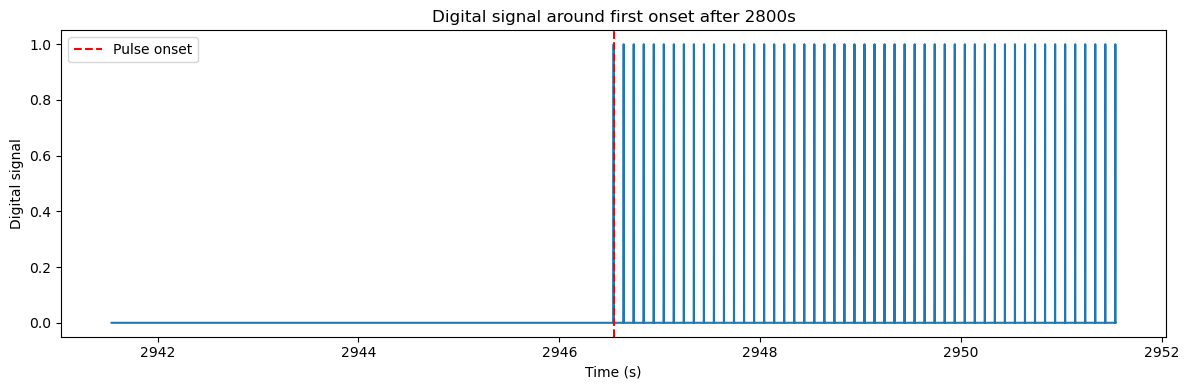

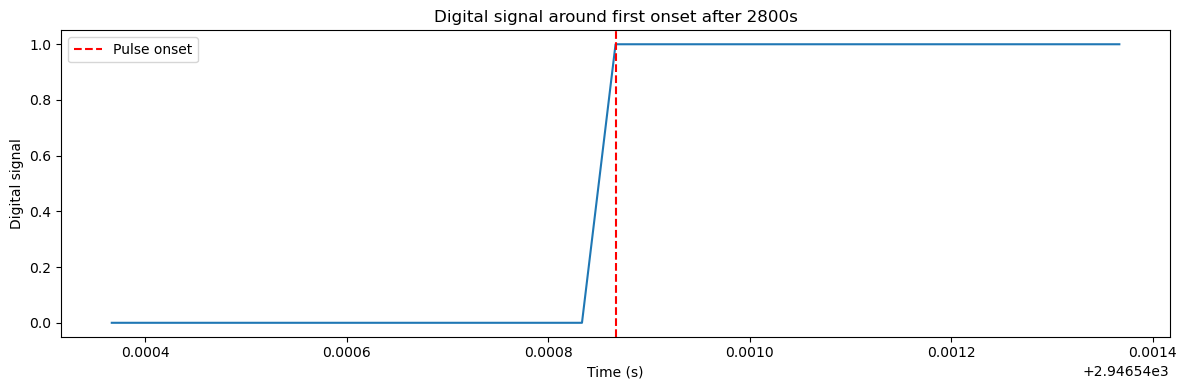

In [38]:
 ---
ipi = np.diff(pulse_times)  # seconds

# --- Identify segments of different pulse frequency ---
threshold = 0.5  # seconds, adjust as needed
segments = []
segment_start = pulse_times[0]
current_freq = 1 / ipi[0] if len(ipi) > 0 else np.nan

for i in range(1, len(ipi)):
    freq = 1 / ipi[i] if ipi[i] > 0 else np.nan
    if abs(freq - current_freq) > 0.5:  # frequency change threshold
        segment_end = pulse_times[i]
        segments.append({
            "start_time": segment_start,
            "end_time": segment_end,
            "frequency": current_freq
        })
        segment_start = segment_end
        current_freq = freq

# Add last segment
if len(ipi) > 0:
    segments.append({
        "start_time": segment_start,
        "end_time": pulse_times[-1],
        "frequency": current_freq
    })

segments_df = pd.DataFrame(segments)

# --- Plot segments ---
plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(digital))[::1000]/fs, digital[::1000], label="Digital signal")
for _, seg in segments_df.iterrows():
    plt.axvspan(seg["start_time"], seg["end_time"], alpha=0.2, color="orange")
plt.xlabel("Time (s)")
plt.ylabel("Digital")
plt.title("Pulse frequency segments")
plt.legend()
plt.xlim(3000, 3100)
plt.show()

# --- Save segments ---
segments_df.to_csv("pulse_frequency_segments.tsv", index=False, sep="\t")
print("Segments with different pulse frequencies:")
print(segments_df.head())

: 

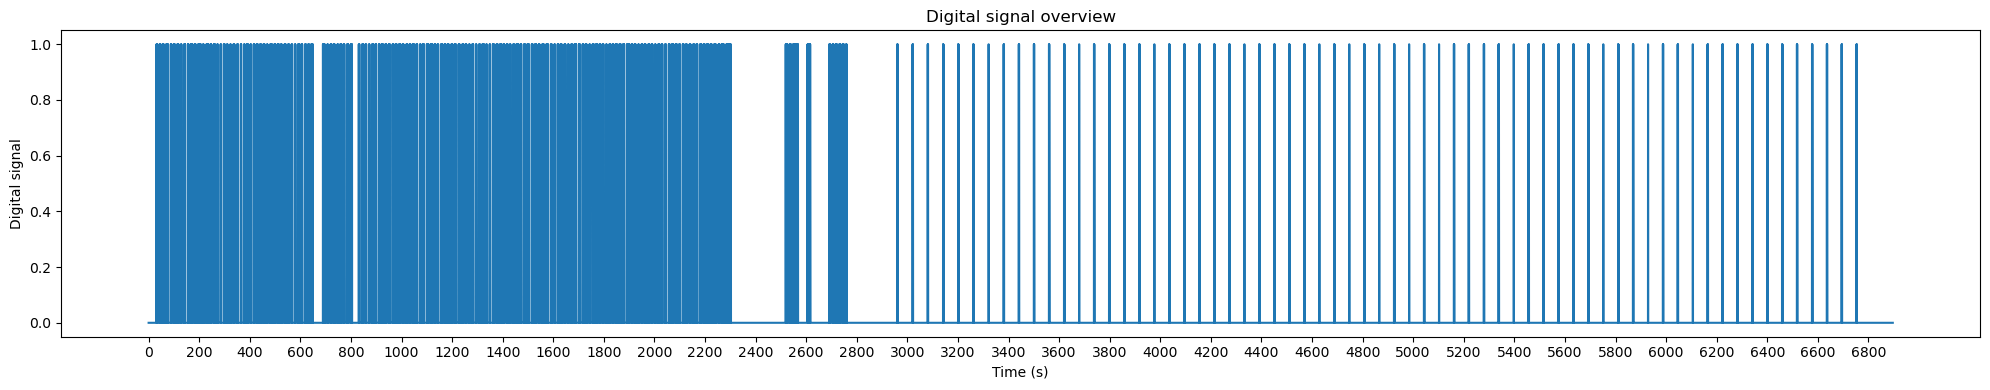

In [15]:
len(pulse_onsets)

239063

In [ ]:
pulse_onsets

In [33]:
import time

# First block timing
start1 = time.time()
loader = GenericEphysLoader(recording_dir, stream_id="0")
_ = loader[:1000]
end1 = time.time()
print(f"GenericEphysLoader: {end1 - start1:.4f} seconds")


# Second block timing
from phylib.io.traces import get_ephys_reader
start2 = time.time()
reader = get_ephys_reader(path, sample_rate=30000, n_channels=64)
_ = reader[:1000]
end2 = time.time()
print(f"phylib.io.traces.FlatEphysReader: {end2 - start2:.4f} seconds")

GenericEphysLoader: 0.4816 seconds
phylib.io.traces.FlatEphysReader: 0.0000 seconds


In [35]:
start2 = time.time()
_ = loader[2000:4000]
end2 = time.time()
print(f"phylib.io.traces.FlatEphysReader: {end2 - start2:.4f} seconds")


phylib.io.traces.FlatEphysReader: 0.0000 seconds


In [16]:


# Just the kwargs
kwargs = extract_ephys_kwargs_from_neo(recording_dir)

# Or directly get the phylib reader
reader = get_reader_from_neo(recording_dir)
traces = reader[0:30000, :]  # first second, lazy chunked access

TypeError: IntanRawIO.__init__() got an unexpected keyword argument 'dirname'

array([[-1.09371765e+108, -6.46476191e+087, -7.98931584e+301, ...,
        -1.49266284e+298, -1.94787763e+290, -1.39173578e+291],
       [-9.60453406e+104, -1.76016573e+084, -8.88476277e+294, ...,
        -5.85077459e+301, -7.48184297e+292, -4.18812203e+291],
       [-1.43215128e+131, -3.65446140e+113, -9.62762816e+295, ...,
        -1.30970165e+281, -3.47704697e+258, -7.64691660e+260],
       ...,
       [ 1.78017622e-307,  3.22642160e-307,  8.83020995e-305, ...,
         3.22668304e-307,  8.06613042e-308,  1.39149875e-309],
       [ 5.28465651e-308,  1.78018811e-307,  2.40328212e-306, ...,
         1.06818348e-306,  8.90077077e-307, -1.01819248e+307],
       [ 3.33759805e-308,  1.06806126e-306,  8.90113574e-308, ...,
         7.83298248e-306,  4.17208988e-308,  8.01133199e-307]],
      shape=(1000, 64))